# Cluster numbers and parities as quasisymmetries: example for H2O

In [ ]:
# Choose type of score. Determines type both of heatmaps and of cost function for orbital optimization.
# Implemented possibilities: 'noncommutativity', 'variance' or 'eval_eq'.
# For 'noncommutativity', operators exp(i 2pi \hat N_cluster/(N_cluster_max + 1)) are also considered.
score_type = 'variance'

# Select an example of cluster number matrix and cluster parity matrix
# Implemented 11 possibilities, indexed 0 through 10; see SECTION 3: ORBITAL OPTIMIZATION
# You can also set to None, and define your own cluster matrices in same section
example_cluster_matrices_index = 4

# molecule parameters
bond_length = 1. 
hoh_angle_deg = 140

In [10]:
# import new functions

import sys
sys.path.insert(0, '..') 
sys.path.append('../src')

import src.heatmaps as heatmaps
import src.cluster_number_operators as cluster_ops

In [11]:
# ============================================================================
# SECTION 1: HAMILTONIAN GENERATION
# ============================================================================
"""
Create molecular Hamiltonian.
This produces a .chk file containing one- and two-electron integrals (AO basis, but easy to transform).
"""

import pyscf
import numpy as np
from scipy.special import binom
from chemistry import get_geometry_and_description


# --- Step 1.1: Define molecular geometry ---
molecule = 'h2o'
geometry, description = get_geometry_and_description(molecule, bond_length, hoh_angle_deg=hoh_angle_deg) # modify depending on molecule parameters
print(f"Geometry: {geometry}")
print(f"Description: {description}")

# --- Step 1.2: Build PySCF molecule and run Hartree-Fock ---
mol = pyscf.M()
mol.build(atom=geometry, basis="sto-3g") # by default, spin_z label is set to 0, or equivalently nelec to (N/2, N/2) (correct for h2o). spin^2 label is not fixed by default (--> can do RHF or HF...). If electron number is odd, crashes if spin not specified
mf = pyscf.scf.RHF(mol)
mf.chkfile = f"../hamiltonians/{description}.chk"  # Will save to this file
mf.kernel()  # Run SCF calculation

# !! From now on and until we start doing orbital rotations, the "orbitals" are always the HF MOs we just obtained.

norb = mol.nao
nelec = mol.nelec
print(f"HF Energy: {mf.e_tot:.8f} Hartree")
print(f"Number of orbitals: {norb}")
print(f"Number of alpha and beta electrons: {nelec}")
print(f"Space dimension (fixed N_alpha, N_beta): {int(binom(mol.nao, mol.nelec[0]) * binom(mol.nao, mol.nelec[1]))}")
# print(f"Coeffs of MOs:\n{mf.mo_coeff}")

Geometry: [('O', (0.0, 0.0, 0.0)), ('H', (np.float64(0.9396926207859083), np.float64(0.3420201433256688), 0.0)), ('H', (np.float64(-0.9396926207859083), np.float64(0.3420201433256688), 0.0))]
Description: H2O_OH1.0000_140.0000
converged SCF energy = -74.9086044445919
HF Energy: -74.90860444 Hartree
Number of orbitals: 7
Number of alpha and beta electrons: (5, 5)
Space dimension (fixed N_alpha, N_beta): 441



FCI Energy: -74.95948442 Hartree

Number of one-orbital num (par) operators (should equal norb = 7): 7 (7)

Number of two-orbital num (par) operators (should equal (norb^2 - norb)/2 = 21): 21 (21)

Variable type of each operator: <class 'scipy.sparse.linalg._interface._CustomLinearOperator'>

Variable type of h: <class 'scipy.sparse.linalg._interface._CustomLinearOperator'>


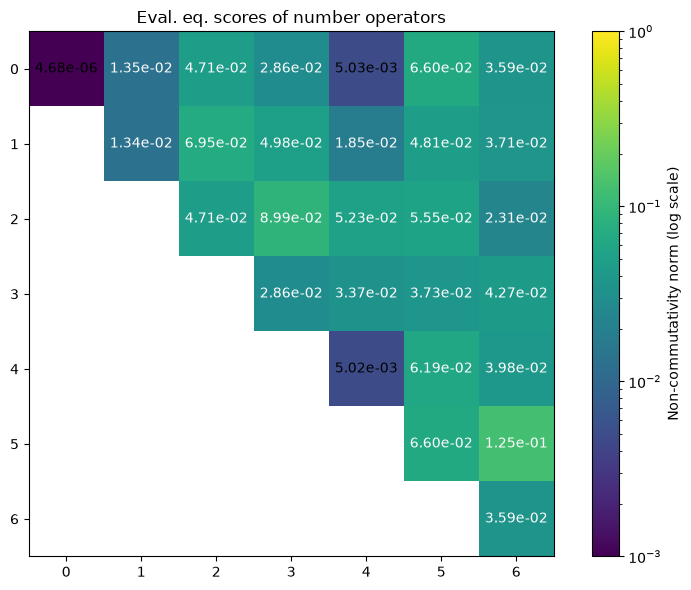

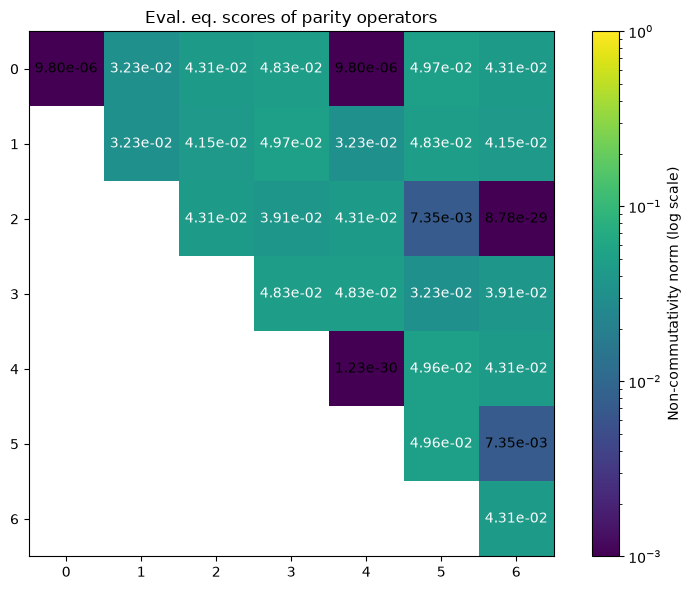

In [12]:
# ============================================================================
# SECTION 2: QUASISYMMETRY DISCOVERY
# ============================================================================
"""
Use show_symmetries.py logic to visualize which single-orbital and two-orbital squared spins have a small commutator "on" for a reference state.

 1. 
Computes non-commutativity scores for:
• single-orbital squared spin i.e. seniority: NC(i,i) = ||[H, S_i^2]|Ψ⟩||² (diagonal)
• two-orbital squared spin: NC(i,j) = ||[H, S_ij^2]|Ψ⟩||² (off-diagonal)
 2. 
Visualizes results as a heatmap (log scale) where:
• Dark spots = small commutator = good quasisymmetry candidate
• Bright spots = poor candidates
"""

import ffsim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import optimize_symmetries
optimize_symmetries.pyscf = pyscf # in case try-except import code in optimize_symmetries fails
optimize_symmetries.ffsim = ffsim # in case try-except import code in optimize_symmetries fails
from optimize_symmetries import parities, get_fci

# --- Step 2.1: Load molecular data using objects mol and mf from previous cell ---
moldata = pyscf.lib.chkfile.load_mol(mf.chkfile)
mf_update = pyscf.scf.RHF(mol) # why again?
mf_update.update_from_chk(mf.chkfile)
moldata_ffsim = ffsim.MolecularData.from_scf(mf_update)

# Prepare the molecular integrals in FCI-compatible format needed by PySCF's FCI solver.
dumpdata = { # (dump means save/write out)
    "NORB": mol.nao,
    "NELEC": mol.nelec,
    "H1": mf.mo_coeff.T @ (mol.intor("int1e_kin") + mol.intor("int1e_nuc")) @ mf.mo_coeff,
    "H2": pyscf.ao2mo.full(mol, mf.mo_coeff),
    "ECORE": mol.energy_nuc()
}

# --- Step 2.2: Compute FCI reference state ---
e_fci, fci_state = get_fci(dumpdata) # optimize_orbitals.get_fci calls pyscf.fci.direct_spin1.FCI
print(f"\nFCI Energy: {e_fci:.8f} Hartree")
# print(f"FCI state: {fci_state}")

# --- Step 2.3: Define one- and two- orb number and parity operators ---

# numbers
one_orb_num_operators = cluster_ops.build_one_orb_num_operators(norb, nelec)
two_orb_num_operators = []
for i in range(norb):
    for j in range(i+1, norb):
        two_orb_num_operators.append(one_orb_num_operators[i] + one_orb_num_operators[j])
# equivalently: two_orb_num_operators = cluster_number.build_two_orb_num_operators(norb, nelec)

# Operators are SciPy's matrix-free linear operator: a lightweight wrapper that knows how to apply the (sparse) operator to a vector. Can also use @, eigsh, ... with it. Good to keep in mind!

# efficiently exponentiated numbers exp(i * pi * number operator/max eval).
# Aim is to treat all sectors on the same footing when evaluating scores.
one_orb_expnum_operators = [cluster_ops.from_num_operator_to_expnum_operator(op, 2) for op in one_orb_num_operators]
two_orb_expnum_operators = [cluster_ops.from_num_operator_to_expnum_operator(op, 4) for op in two_orb_num_operators]

# parities
one_orb_par_operators = parities(norb, nelec) # Aleksey's implementation
two_orb_par_operators = []
for i in range(norb):
    for j in range(i+1, norb):
        two_orb_par_operators.append(one_orb_par_operators[i] @ one_orb_par_operators[j])

print(f"\nNumber of one-orbital num (par) operators (should equal norb = {norb}): {len(one_orb_num_operators)} ({len(one_orb_par_operators)})")
print(f"\nNumber of two-orbital num (par) operators (should equal (norb^2 - norb)/2 = {(norb**2 - norb)//2}): {len(two_orb_num_operators)} ({len(two_orb_par_operators)})")
example_op = one_orb_num_operators[0]
print(f"\nVariable type of each operator: {type(example_op)}")

# --- Step 2.4: Compute scores and show heatmaps ---
h = ffsim.linear_operator(moldata_ffsim.hamiltonian, norb, nelec) # the hamiltonian refers to HF MO orbital basis; this is the line of this cell where we are choosing the reference orbital basis
print(f"\nVariable type of h: {type(h)}") # same "wrapper" type

if score_type == 'noncommutativity':
    nc_scores_num = heatmaps.get_heatmap_data_nc_score(h, fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)
    nc_scores_expnum = heatmaps.get_heatmap_data_nc_score(h, fci_state, norb, one_orb_expnum_operators, two_orb_expnum_operators, upscale_factor=1)
    nc_scores_par = heatmaps.get_heatmap_data_nc_score(h, fci_state, norb, one_orb_par_operators, two_orb_par_operators, upscale_factor=1)

    heatmaps.show_heatmap(nc_scores_num, vmin=1e-3, vmax=1e0, title='Comm. scores of number operators')
    heatmaps.show_heatmap(nc_scores_expnum, vmin=1e-3, vmax=1e0, title='Comm. scores of exp. number operators')
    heatmaps.show_heatmap(nc_scores_par, vmin=1e-3, vmax=1e0, title='Comm. scores of parity operators')

if score_type == 'variance':
    variance_scores_num = heatmaps.get_heatmap_data_variance_score(fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)
    variance_scores_par = heatmaps.get_heatmap_data_variance_score(fci_state, norb, one_orb_par_operators, two_orb_par_operators, upscale_factor=1)

    heatmaps.show_heatmap(variance_scores_num, vmin=1e-3, vmax=1e0, title='Variance scores of number operators')
    heatmaps.show_heatmap(variance_scores_par, vmin=1e-3, vmax=1e0, title='Variance scores of parity operators')

if score_type == 'eval_eq':
    one_orb_num_evals = [round(np.real(fci_state.T.conj() @ op @ fci_state)) for op in one_orb_num_operators] # best guess of eigenvalues
    two_orb_num_evals = [round(np.real(fci_state.T.conj() @ op @ fci_state)) for op in two_orb_num_operators] # same
    eval_eq_scores_num = heatmaps.get_heatmap_data_eval_eq_score(fci_state, norb, one_orb_num_operators, two_orb_num_operators, one_orb_num_evals, two_orb_num_evals, upscale_factor=1)
    one_orb_par_evals = [np.sign(fci_state.T.conj() @ op @ fci_state) for op in one_orb_par_operators]
    two_orb_par_evals = [np.sign(fci_state.T.conj() @ op @ fci_state) for op in two_orb_par_operators]
    eval_eq_scores_par = heatmaps.get_heatmap_data_eval_eq_score(fci_state, norb, one_orb_par_operators, two_orb_par_operators, one_orb_par_evals, two_orb_par_evals, upscale_factor=1)

    heatmaps.show_heatmap(eval_eq_scores_num, vmin=1e-3, vmax=1e0, title='Eval. eq. scores of number operators')
    heatmaps.show_heatmap(eval_eq_scores_par, vmin=1e-3, vmax=1e0, title='Eval. eq. scores of parity operators')

"""
NOTES ON SECTION 2:
- Dark spots in the heatmap indicate good quasisymmetry candidates
"""

print()


Cluster number matrix (7 quasisymmetries, 7 orbitals):
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]

Cluster parity matrix (0 quasisymmetries, 7 orbitals):
[]
Using cluster numbers or exponentiated cluster numbers: use_exp_cluster_number = False
Number of quasisymmetry operators: 7

Initial cost (identity rotation): 1.961269e-01

Running orbital optimization...


/var/folders/r2/2ny_rjqj5w93mz1ll0gd2vbr0000gp/T/ipykernel_13375/1387655290.py:179: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = scipy.optimize.minimize(


Optimized cost: 1.835847e-01
Cost change: -6.39%

For reference, % cost change for some random unitaries: 4271, 560, 5441%

New heatmaps after orbital optimization (relevant if clusters have one or two orbitals):


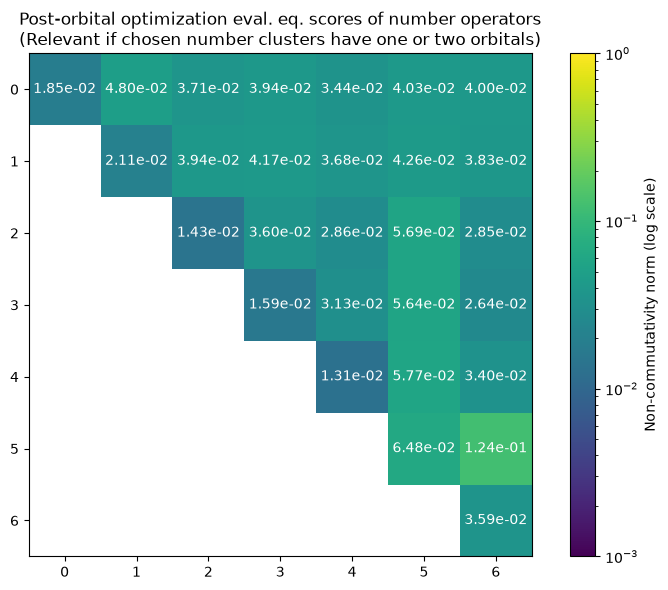

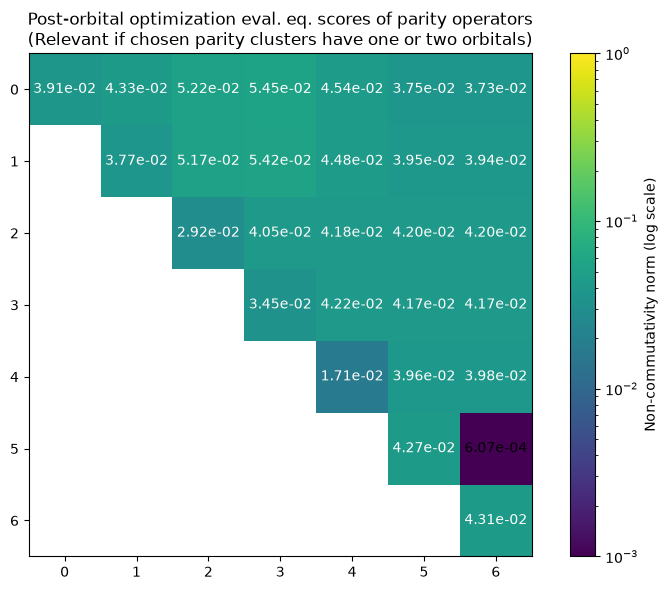

In [13]:
# ============================================================================
# SECTION 3: ORBITAL OPTIMIZATION
# ============================================================================
"""
Now we:
1. Select one or more quasisymmetries (based on heatmap), i.e., cluster numbers or parities
2. Optimize the orbital rotation to minimize the commutator cost.
Need to try to avoid redundancies, e.g., using both number n_i and parity (-1)^n_i for some i;
or having number/parity operators relative to complementary clusters 

"""

from optimize_symmetries import parity_matrix_to_quasisymmetries, x_to_rotation, commutator_cost, variance_cost_general, eval_eq_cost
import scipy.optimize
from math import comb

# --- Step 3.1: Define the cluster number matrix and the cluster parity matrix; refers to spatial orbitals ---

# either define custom cluster matrices...

#cluster_number_matrix = np.array([
#    [1, 0, 0, 0, 1, 0, 0],
#    [0, 0, 1, 1, 0, 0, 1],
#    [0, 1, 0, 1, 0, 1, 0]
#])
#cluster_parity_matrix = np.array([])

# ...or choose as instructed in second cell:

example_cluster_matrices = []

# choice 0: each cluster = 1 orbital; orbitals 0-2 -> numbers; orbitals 3-5 -> parities
example_cluster_number_matrix = np.array([
    [1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0]
])
example_cluster_parity_matrix = np.array([
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 1: some cluster numbers, with |cluster| >= 2 orbitals; no cluster parities
example_cluster_number_matrix = np.array([
    [1, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1],
    [0, 1, 0, 1, 0, 1, 0]
])
example_cluster_parity_matrix = np.array([])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 2: choice 1, but switching number and parity matrices
example_cluster_number_matrix = np.array([])

example_cluster_parity_matrix = np.array([
    [1, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1],
    [0, 1, 0, 1, 0, 1, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 3: some pairs of orbitals whose corresponding heat map tile is darkest; and one parity cluster
example_cluster_number_matrix = np.array([
    [0, 0, 1, 1, 0, 0, 0],
    [1, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0]
])
example_cluster_parity_matrix = np.array([
    [1, 1, 1, 0, 0, 0, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 4: all one-orb numbers, taken singularly (-> no cluster parities)
example_cluster_number_matrix = np.eye(7)
example_cluster_parity_matrix = np.array([])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 5 (QSENSE): no cluster numbers, all one-orb parities, taken singularly
example_cluster_number_matrix = np.array([]) 
example_cluster_parity_matrix = np.eye(7)
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 6: numbers for pairs of orbitals whose corresponding heat map tile is darkest; no parities
example_cluster_number_matrix = np.array([
    [1, 0, 0, 0, 1, 0, 0,],
    [0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 1, 0, 1, 0]
])
example_cluster_parity_matrix = np.array([])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 7: same as above, but only orbital-pair parities
example_cluster_number_matrix = np.array([])
example_cluster_parity_matrix = np.array([
    [1, 0, 0, 0, 1, 0, 0,],
    [0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 1, 0, 1, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 8: only parities, random
example_cluster_number_matrix = np.array([])
example_cluster_parity_matrix = np.array([
    [1, 0, 0, 0, 0, 0, 0,],
    [0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))


# choice 9: only one big parity
example_cluster_number_matrix = np.array([])
example_cluster_parity_matrix = np.array([
    [1, 1, 1, 0, 0, 0, 0,]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# choice 10: overload of parities
example_cluster_number_matrix = np.array([])
example_cluster_parity_matrix = np.array([
    [1, 0, 0, 0, 0, 0, 0,],
    [0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0],
    [1, 0, 1, 1, 0, 0, 0,],
    [0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 0]
])
example_cluster_matrices.append((example_cluster_number_matrix, example_cluster_parity_matrix))

# example_cluster_matrices_index (set in cell 2)
if example_cluster_matrices_index != None:
    cluster_number_matrix, cluster_parity_matrix = example_cluster_matrices[example_cluster_matrices_index]

print(f"\nCluster number matrix ({cluster_number_matrix.shape[0]} quasisymmetries, {norb} orbitals):")
print(cluster_number_matrix)

print(f"\nCluster parity matrix ({cluster_parity_matrix.shape[0]} quasisymmetries, {norb} orbitals):")
print(cluster_parity_matrix)

# --- Step 3.2: Convert cluster matrices to lists of quasisymmetry operators ---

use_exp_cluster_number = False # set to True to use exp(i pi cluster_number_op / (N_max + 1)), to treat sectors on the same foot (possibly more accurate, but more expensive)
print(f"Using cluster numbers or exponentiated cluster numbers: use_exp_cluster_number = {use_exp_cluster_number}")

cluster_number_operators = cluster_ops.number_matrix_to_operators(
    cluster_number_matrix, norb, nelec, expnum=use_exp_cluster_number)

cluster_parity_operators = parity_matrix_to_quasisymmetries( # Aleksey's implementation
    cluster_parity_matrix, norb, nelec)

# join
quasisymmetry_operators = cluster_number_operators + cluster_parity_operators
print(f"Number of quasisymmetry operators: {len(quasisymmetry_operators)}")

# --- Step 3.3: Define the cost function ---
# We optimize over orbital rotation parameters x (anti-symmetric matrix)
# define cost function
if score_type == 'noncommutativity':
    # Cost = sum over symmetries S_k of ||[H(U), S_k]|Ψ(U)⟩||²
    f = commutator_cost(moldata_ffsim, quasisymmetry_operators, fci_state) # commutator_cost builds the cost function f: x upper triangle of antisym matrix |-> \sum_k ||[H(rotated with exp(x)), S_k]|Ψ(rotated with exp(x)⟩||²
if score_type == 'variance':
    # sym:variance_cost
    f = variance_cost_general(moldata_ffsim, quasisymmetry_operators, fci_state)
if score_type == 'eval_eq':
    cluster_number_evals = [round(np.real(fci_state.T.conj() @ (op @ fci_state))) for op in cluster_number_operators] # best guess of eigenvalues
    cluster_parity_evals = [np.sign(fci_state.T.conj() @ (op @ fci_state)) for op in cluster_parity_operators] # same
    evals = cluster_number_evals + cluster_parity_evals
    f = eval_eq_cost(quasisymmetry_operators, evals, fci_state, norb, nelec)

# --- Step 3.4: Initial guess (identity rotation) ---
x0 = np.zeros(comb(norb, 2))
initial_cost = f(x0)
print(f"\nInitial cost (identity rotation): {initial_cost:.6e}")

# --- Step 3.5: Optimize using L-BFGS-B ---
print("\nRunning orbital optimization...")
result = scipy.optimize.minimize(
    f, x0,
    method='L-BFGS-B',
    options={'maxiter': 100, 'disp': True}
)
optimized_cost = result.fun
print(f"Optimized cost: {optimized_cost:.6e}")
print(f"Cost change: {(- initial_cost + optimized_cost)/initial_cost * 100:.2f}%")

# --- Step 3.6: Extract optimized orbital rotation ---
x_opt = result.x
U_opt = x_to_rotation(x_opt, norb)
# print(f"\nOptimized rotation matrix U:")
# print(U_opt)

# --- Step 3.7: Compare with randomly rotated orbitals ---
num_random_Us = 3
xs_random = [10 * np.random.rand(comb(norb, 2)) for _ in range(num_random_Us)]
random_costs = [f(x_random) for x_random in xs_random]
random_costs_perc = [int((- initial_cost + random_cost)/initial_cost * 100) for random_cost in random_costs]
print(f"\nFor reference, % cost change for some random unitaries: {', '.join(map(str, random_costs_perc))}%")

# --- Step 3.8: New heatmap with optimally rotated orbitals ---

# get rotated Ham and state using same convention as in cost function (see optimize_symmetries.commutator_cost)
rotated_h = moldata_ffsim.hamiltonian.rotated(U_opt)
rotated_h_linop = ffsim.linear_operator(rotated_h, norb, nelec)
rotated_fci_state = ffsim.apply_orbital_rotation(
    fci_state, U_opt, norb, nelec)

print("\nNew heatmaps after orbital optimization (relevant if clusters have one or two orbitals):")

if score_type == 'noncommutativity':
    rotated_nc_scores_num = heatmaps.get_heatmap_data_nc_score(rotated_h_linop, rotated_fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)
    rotated_nc_scores_expnum = heatmaps.get_heatmap_data_nc_score(rotated_h_linop, rotated_fci_state, norb, one_orb_expnum_operators, two_orb_expnum_operators, upscale_factor=1)
    rotated_nc_scores_par = heatmaps.get_heatmap_data_nc_score(rotated_h_linop, rotated_fci_state, norb, one_orb_par_operators, two_orb_par_operators, upscale_factor=1)
    heatmaps.show_heatmap(rotated_nc_scores_num, vmin=1e-3, vmax=1e0, title='Post-orbital optimization comm. scores of number operators\n(Relevant if chosen number clusters have one or two orbitals and using non exp. numbers)')
    heatmaps.show_heatmap(rotated_nc_scores_expnum, vmin=1e-3, vmax=1e0, title='Post-orbital optimization comm. scores of exp. number operators\n(Relevant if chosen number clusters have one or two orbitals and using exp. numbers)')
    heatmaps.show_heatmap(rotated_nc_scores_par, vmin=1e-3, vmax=1e0, title='Post-orbital optimization comm. scores of parity operators\n(Relevant if chosen parity clusters have one or two orbitals)')

if score_type == 'variance':
    rotated_variance_scores_num = heatmaps.get_heatmap_data_variance_score(rotated_fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)
    rotated_variance_scores_par = heatmaps.get_heatmap_data_variance_score(rotated_fci_state, norb, one_orb_par_operators, two_orb_par_operators, upscale_factor=1)
    heatmaps.show_heatmap(rotated_variance_scores_num, vmin=1e-3, vmax=1e0, title='Post-orbital optimization variance scores of number operators\n(Relevant if chosen number clusters have one or two orbitals)')
    heatmaps.show_heatmap(rotated_variance_scores_par, vmin=1e-3, vmax=1e0, title='Post-orbital optimization variance scores of parity operators\n(Relevant if chosen parity clusters have one or two orbitals)')

if score_type == 'eval_eq':
    rotated_one_orb_num_evals = [round(np.real(rotated_fci_state.T.conj() @ op @ rotated_fci_state)) for op in one_orb_num_operators]
    rotated_two_orb_num_evals = [round(np.real(rotated_fci_state.T.conj() @ op @ rotated_fci_state)) for op in two_orb_num_operators]
    rotated_eval_eq_scores_num = heatmaps.get_heatmap_data_eval_eq_score(rotated_fci_state, norb, one_orb_num_operators, two_orb_num_operators, one_orb_num_evals, two_orb_num_evals, upscale_factor=1)
    rotated_one_orb_par_evals = [np.sign(rotated_fci_state.T.conj() @ op @ rotated_fci_state) for op in one_orb_par_operators]
    rotated_two_orb_par_evals = [np.sign(rotated_fci_state.T.conj() @ op @ rotated_fci_state) for op in two_orb_par_operators]
    rotated_eval_eq_scores_par = heatmaps.get_heatmap_data_eval_eq_score(rotated_fci_state, norb, one_orb_par_operators, two_orb_par_operators, one_orb_par_evals, two_orb_par_evals, upscale_factor=1)
    heatmaps.show_heatmap(rotated_eval_eq_scores_num, vmin=1e-3, vmax=1e0, title='Post-orbital optimization eval. eq. scores of number operators\n(Relevant if chosen number clusters have one or two orbitals)')
    heatmaps.show_heatmap(rotated_eval_eq_scores_par, vmin=1e-3, vmax=1e0, title='Post-orbital optimization eval. eq. scores of parity operators\n(Relevant if chosen parity clusters have one or two orbitals)')

"""
NOTES ON SECTION 3:
- The optimization finds U that minimizes the selected cost function
- The orbital rotation U transforms the molecular orbitals to a new basis
where the quasisymmetries commute better with the Hamiltonian.
"""

print("\n")



Number of alpha/beta elecs: (5, 5)
Corresponding total number of configurations = total dimension: 441
Number of symmetry sectors identified: 161

State projections in sectors (ordered by norm squared):
Projection of rotated_fci_state into sector ((2, 2, 2, 2, 2, 0, 0), ()): norm squared = 0.969714, energy of projection = -74.907901
Projection of rotated_fci_state into sector ((1, 1, 2, 2, 2, 2, 0), ()): norm squared = 0.004034, energy of projection = -70.929995
Projection of rotated_fci_state into sector ((1, 2, 2, 1, 2, 1, 1), ()): norm squared = 0.002288, energy of projection = -61.798444
Projection of rotated_fci_state into sector ((2, 1, 2, 1, 2, 1, 1), ()): norm squared = 0.002115, energy of projection = -62.651624
Projection of rotated_fci_state into sector ((2, 0, 2, 2, 2, 2, 0), ()): norm squared = 0.001965, energy of projection = -71.653397
Projection of rotated_fci_state into sector ((1, 2, 1, 2, 2, 1, 1), ()): norm squared = 0.001932, energy of projection = -64.177853
Proj

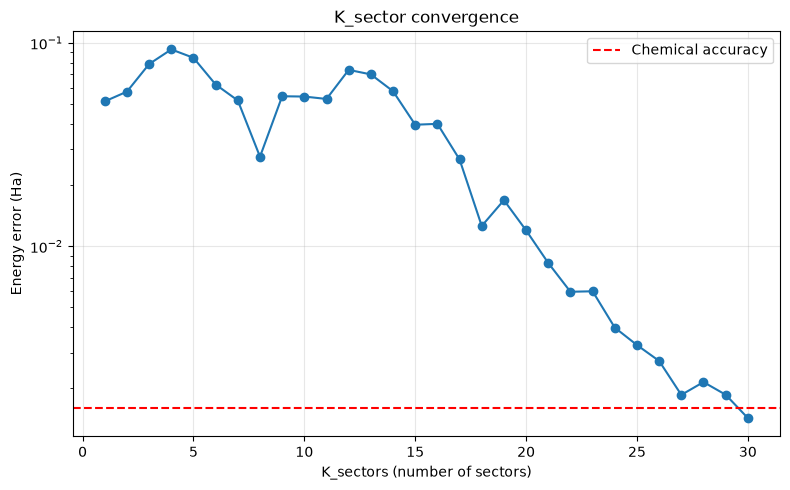

In [14]:
# ============================================================================
# SECTION 4: METRICS EVALUATION - part A: sectors
# ============================================================================
"""
Now we evaluate the quality of the sector decomposition based on quasisymmetry sectors, by:
1. Identifying sectors
2. Plotting K_sectors -> energy and comparing with chemical accuracy = 1.6 mHa = 0.0016 Hartree. We sort sectors by their contribution to the FCI state and
accumulate until the projected energy is within 0.0016 Ha of FCI.

We thus get number K_sectors needed to recover the FCI ground state energy to chemical accuracy.
"""
from src.sector_utils import subspace_matrix
import scipy
def orthogonalize_degenerate(w, V, tol=1e-10):
    """scipy.sparse.linalg.eigsh sometimes returns non-orthogonal eigenvectors if they have
    degenerate eigenvalues. This function rectifies that."""
    V_orth = V.copy()

    start = 0
    while start < len(w):
        end = start + 1
        while end < len(w) and abs(w[end] - w[start]) < tol:
            end += 1

        # Orthogonalize this degenerate block
        Q, _ = scipy.linalg.qr(V[:, start:end], mode="economic")
        V_orth[:, start:end] = Q

        start = end
    return V_orth
from chemistry import CHEMICAL_PRECISION
from math import comb

# --- Step 4.1: Identify symmetry sectors by partitioning the computational/fock basis --- 
# Each configuration/bitstring/basis SD gets assigned to a sector based on
# the eigenvalues of our quasisymmetries
sectors = cluster_ops.number_and_parity_symmetry_sectors(cluster_number_matrix, cluster_parity_matrix, norb, nelec)
print(f"\nNumber of alpha/beta elecs: {nelec}")
print(f"Corresponding total number of configurations = total dimension: {comb(norb, nelec[0]) * comb(norb, nelec[1])}")
print(f"Number of symmetry sectors identified: {len(sectors)}")
# for sector_label, sector_indices in sectors.items():
    # print(f"  Sector {sector_label}: {len(sector_indices)} configurations")
# print(f"Sectors full dict: {sectors} \n")

state_projections_in_sectors = {} # key = sector label (as in sectors), value = (projection of rotated_fci_state into sectors, norm squared)
for sector_label, sector_indices in sectors.items():
    projection = np.zeros(rotated_fci_state.shape, dtype='complex')
    projection[sector_indices] = rotated_fci_state[sector_indices]
    norm_squared = np.linalg.norm(projection)**2
    energy = np.real(projection.T.conj() @ rotated_h_linop @ projection / norm_squared) if norm_squared > 0 else np.nan
    state_projections_in_sectors[sector_label] = (projection, norm_squared, energy)

# --- Step 5.6: K_sectors ---

# order state_projections_in_sectors projections by norm_squared
ordered_state_projections_in_sectors = sorted(state_projections_in_sectors.items(), key=lambda x: x[1][1], reverse=True)
print(f"\nState projections in sectors (ordered by norm squared):")
for sector_label, (projection, norm_squared, energy) in ordered_state_projections_in_sectors:
    print(f"Projection of rotated_fci_state into sector {sector_label}: norm squared = {norm_squared:.6f}, energy of projection = {energy:.6f}")
print()

def projected_energy_sectors(K_sector):
    """Compute energy using only the K_sector most important sectors"""
    # Create compressed coefficient vector
    compressed_coeffs = np.zeros_like(rotated_fci_state, dtype='complex')
    for i in range(K_sector):
        sector_label, (projection, norm_squared, energy) = ordered_state_projections_in_sectors[i]
        compressed_coeffs += projection

    # Normalize
    compressed_coeffs /= np.linalg.norm(compressed_coeffs)

    # Compute energy
    e_proj = compressed_coeffs.T.conj() @ rotated_h_linop @ compressed_coeffs
    return e_proj.real

# Convergence in the number of sector states retained
K_sectors_values = []
K_sectors_energies = []
for K_sectors in range(1, len(ordered_state_projections_in_sectors) + 1):
    K_sectors_values.append(K_sectors)
    e_K = projected_energy_sectors(K_sectors)
    K_sectors_energies.append(e_K)
    error = e_K - e_fci
    print(f"K_sector={K_sectors:2d}: E={e_K:.8f}, Error={error:.8f} Ha = {error*27.2114:.4f} eV")
    if error < CHEMICAL_PRECISION:
        print(f"--> Chemical accuracy achieved at K_sector={K_sectors}!")
        break

# Plot energy error vs K_sector
plt.figure(figsize=(8, 5))
plt.plot(K_sectors_values, [e - e_fci for e in K_sectors_energies], 'o-')
plt.axhline(CHEMICAL_PRECISION, color='r', linestyle='--', label='Chemical accuracy')
plt.xlabel('K_sectors (number of sectors)')
plt.ylabel('Energy error (Ha)')
plt.title('K_sector convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

"""
NOTES ON SECTION 4:
- K_sectors=1 means a single sector recovers chemical accuracy
- For well-chosen quasisymmetries, K_sectors is much smaller than the total number of sectors
- The energy error plot shows how quickly we converge to FCI

PHYSICAL INTERPRETATION:
When K is small, it means the quasisymmetry successfully decomposes the
Hilbert space such that the ground state has weight on only a few sectors.
"""
print()

 
Sector ((2, 2, 2, 2, 2, 0, 0), ()): 1 states, ground energy = -74.90790072
Sector ((2, 2, 2, 2, 1, 1, 0), ()): 2 states, ground energy = -73.94438983
Sector ((2, 2, 2, 1, 2, 1, 0), ()): 2 states, ground energy = -64.92407309
Sector ((2, 2, 1, 2, 2, 1, 0), ()): 2 states, ground energy = -67.22888949
Sector ((2, 1, 2, 2, 2, 1, 0), ()): 2 states, ground energy = -73.51460424
Sector ((1, 2, 2, 2, 2, 1, 0), ()): 2 states, ground energy = -72.77292026
Sector ((2, 2, 2, 2, 1, 0, 1), ()): 2 states, ground energy = -73.68782202
Sector ((2, 2, 2, 1, 2, 0, 1), ()): 2 states, ground energy = -64.71307738
Sector ((2, 2, 1, 2, 2, 0, 1), ()): 2 states, ground energy = -67.00749645
Sector ((2, 1, 2, 2, 2, 0, 1), ()): 2 states, ground energy = -73.28696906
Sector ((1, 2, 2, 2, 2, 0, 1), ()): 2 states, ground energy = -72.48224577
Sector ((2, 2, 2, 1, 1, 1, 1), ()): 6 states, ground energy = -63.82852183
Sector ((2, 2, 1, 2, 1, 1, 1), ()): 6 states, ground energy = -66.10646695
Sector ((2, 1, 2, 2, 1,

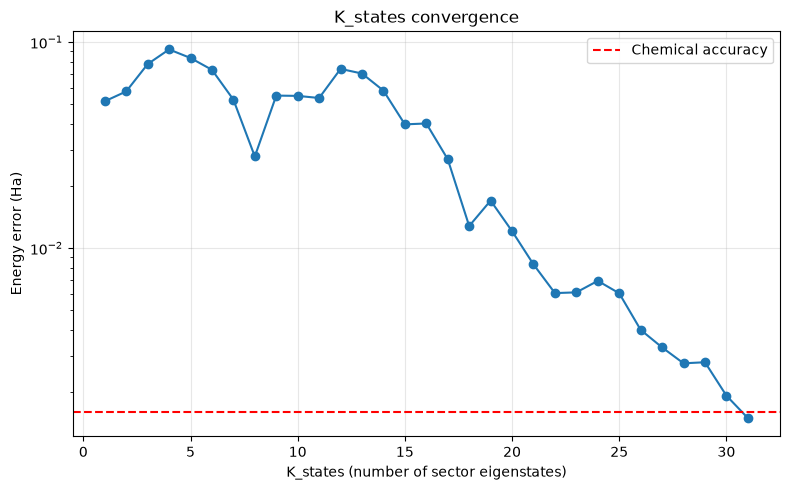

In [15]:

# ============================================================================
# SECTION 5: METRICS EVALUATION - part B: sector eigenstates
# ============================================================================
""""
We evaluate the quality of the sector decomposition based on the subspace-restriced Hamiltonians, by:
1. Building sector Hamiltonians
2. Plotting K_states -> energy and comparing with chemical accuracy = 1.6 mHa = 0.0016 Hartree. We sort sector Hamiltonian eigenstates *distributed across sectors* by their contribution to the FCI state and accumulate until the projected energy is within 0.0016 Ha of FCI.

We thus get for number K_states needed to recover the FCI ground state energy to chemical accuracy.
"""

# --- Step 5.1: Build subspace Hamiltonians ---
sector_hamiltonians = {}
for sector_label, sector_indices in sectors.items():
    sector_hamiltonians[sector_label] = subspace_matrix( # should still be able to reuse Aleksey's subspace_matrix here!
        rotated_h_linop, sector_indices)                # (although can substitute with std submatrix extraction functions)
    #print(f"  Sector {sector_label}: Hamiltonian shape {sector_hamiltonians[sector_label].shape}")

print(" ")

# --- Step 5.2: Diagonalize each sector --- # I will keep this part, although not what I am most interested about
sector_energies = {}
sector_states = {}
for label, h_sub in sector_hamiltonians.items():
    # Get all eigenvalues (full diagonalization for small systems)
    w, v = np.linalg.eigh(h_sub)
    v_orth = orthogonalize_degenerate(w, v)
    sector_energies[label] = w
    sector_states[label] = v_orth
    print(f"Sector {label}: {len(w)} states, ground energy = {w[0]:.8f}")

# --- Step 5.3: Find the global ground state in decoupled sectors ---
# Each sector has its own ground state. The true ground state is the minimum.
sector_ground_energies = {label: energies[0] for label, energies in sector_energies.items()}
global_min_sector = min(sector_ground_energies, key=sector_ground_energies.get)
e_decoupled = sector_ground_energies[global_min_sector]
print(f"\nDecoupled ground state energy: {e_decoupled:.8f}")
print(f"FCI energy: {e_fci:.8f}")
print(f"Energy error: {e_decoupled - e_fci:.8f} Hartree = {(e_decoupled - e_fci)*27.2114:.4f} eV")

# --- Step 5.4: Construct full-space basis from sector states ---
# Collect all sector states into a single matrix
full_space_vectors = []
sector_labels_list = []
for label, indices in sectors.items():
    # Get the states for this sector
    v_sector = sector_states[label]
    n_states = v_sector.shape[1]

    # Create full-space vectors (zeros everywhere except in this sector)
    vectors_in_sector = np.zeros((rotated_h_linop.shape[0], n_states),
                                dtype='complex')
    vectors_in_sector[indices, :] = v_sector
    full_space_vectors.append(vectors_in_sector)

    # Track which sector each state belongs to
    for i in range(n_states):
        sector_labels_list.append((label, i))

# print(f"\n Full space vectors (each column is an eigenvector of the QSs and of the hamiltonian restricted to the corresponding QS sector): \n{full_space_vectors}") # basis ordering for two orbitals and Nalpha = Nbeta = 1: |alpha beta, 0>, |alpha, beta>, |beta, alpha>, |0, alpha beta>

# Concatenate all sector states
full_space_vectors_cat = np.concatenate(full_space_vectors, axis=1) # block diag unitary up to reordering only columns or only rows, i.e., full change of basis matrix from initial SDs to basis of simultaneous eigenvectors of the QSs and of the hamiltonian restricted ("sector hamiltonian eigenvectors")
# print(f"\nfull_space_vectors_cat: \n {full_space_vectors_cat}")
# print(f"\nTotal number of sector states: {full_space_vectors_cat.shape[1]}")
# print(f"Full Hilbert space dimension: {rotated_h_linop.shape[0]}")

# --- Step 5.5: Project FCI state onto sector states ---
# Get fci state in basis of sector hamiltonian eigenvectors
coefficients = full_space_vectors_cat.T.conj() @ rotated_fci_state
# print(f"\nFCI state coefficients in sector basis:")
# for i, (label, state_idx) in enumerate(sector_labels_list):
#    print(f"Sector {label}, state {state_idx}: |c|² = {np.abs(coefficients[i])**2:.9f}")

# --- Step 5.6: K_states ---

# Sort coefficients by magnitude (most important first)
sorted_indices = np.argsort(np.abs(coefficients))[::-1]

# Function to compute projected energy using top K states; see metrics.py; rewritten here for clarity
def projected_energy_states(K_states):
    """Compute energy using only the K_states most important sector eigenstates"""
    # Create compressed coefficient vector
    compressed_coeffs = np.zeros_like(coefficients, dtype='complex')
    compressed_coeffs[sorted_indices[:K_states]] = coefficients[sorted_indices[:K_states]]

    # Normalize
    compressed_coeffs /= np.linalg.norm(compressed_coeffs)

    # Projected state in same representation as as rotated_fci_state
    projected_state = full_space_vectors_cat @ compressed_coeffs
    projected_state /= np.linalg.norm(projected_state) # redundant

    # Compute energy
    e_proj = projected_state.T.conj() @ rotated_h_linop @ projected_state
    return e_proj.real

# Find minimal K_states
K_states_values = []
K_states_energies = []
for K_states in range(1, len(coefficients) + 1):
    K_states_values.append(K_states)
    e_K = projected_energy_states(K_states)
    K_states_energies.append(e_K)
    error = e_K - e_fci
    print(f"K={K_states:2d}: E={e_K:.8f}, Error={error:.8f} Ha = {error*27.2114:.4f} eV")
    if error < CHEMICAL_PRECISION:
        print(f"--> Chemical accuracy achieved at K={K_states}!")
        break

# Plot energy error vs K
plt.figure(figsize=(8, 5))
plt.plot(K_states_values, [(e - e_fci).round(6) for e in K_states_energies], 'o-')
plt.axhline(CHEMICAL_PRECISION, color='r', linestyle='--', label='Chemical accuracy')
plt.axhline(0, color='k', linestyle=':', alpha=0.3)
plt.xlabel('K_states (number of sector eigenstates)')
plt.ylabel('Energy error (Ha)')
plt.title(f'K_states convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

"""
NOTES ON SECTION 5:
- K_states=1 means the ground state of a single sector recovers chemical accuracy
- the K_states restricted-hamiltonian eigenstates are chosen *across all sectors*
- For well-chosen quasisymmetries, K is much smaller than the full Hilbert space
- The energy error plot shows how quickly we converge to FCI

PHYSICAL INTERPRETATION:
When K is small, it means the quasisymmetry successfully decomposes the
Hilbert space such that the ground state is well-approximated by a small
number of restricted-hamiltonian states from a few sectors.
"""

print("\n")

In [16]:

# ============================================================================
# SECTION 6: COMPLETE WORKFLOW SUMMARY
# ============================================================================



# molecule details
molecule = "h2o"
bond_length = 1. 
hoh_angle_deg = 30

print("\n" + "="*70)
print("WORKFLOW SUMMARY")
print("="*70)
print(f"Molecule: {molecule}")
print(f"Bond length: {bond_length}")
print(f"Angle: {hoh_angle_deg}")
print(f"Basis: STO-3G ({norb} spatial orbitals)")
print(f"Electrons: {mol.nelec}")
print()
print(f"1. Hamiltonian Generation:")
print(f"   - HF Energy: {mf.e_tot:.8f} Ha")
print(f"   - FCI Energy: {e_fci:.8f} Ha")
print()
print(f"2. Quasisymmetry Discovery:")
print(f"   - Tested {norb} single-orbital numbers and {comb(norb,2)} orbital-pair-numbers")
print()
print(f"3. Orbital Optimization:")
print(f"   - Score type: {score_type}")
print(f"   - Cluster number matrix:\n{cluster_number_matrix}")
print(f"   - Cluster parity matrix:\n{cluster_parity_matrix}")
print(f"   - Initial cost: {initial_cost:.6e}")
print(f"   - Optimized cost: {optimized_cost:.6e}")
print(f"   - Cost reduction: {(initial_cost - optimized_cost)/initial_cost * 100:.2f}%")
print()
print(f"4. Metrics Evaluation:")
print(f"   - Number of sectors: {len(sectors)}")
print(f"   - Decoupled ground energy: {e_decoupled:.8f} Ha")
print(f"   - Energy error (decoupled): {e_decoupled - e_fci:.8f} Ha")
print(f"   - K values: K_sectors={K_sectors} sectors, or K_states={K_states} sector Hamiltonian eigenstates (distributed across sectors), are needed for chemical accuracy")
print(f"   - Full space dimension: {rotated_h_linop.shape[0]}")
#TODO print from last cell


WORKFLOW SUMMARY
Molecule: h2o
Bond length: 1.0
Angle: 30
Basis: STO-3G (7 spatial orbitals)
Electrons: (5, 5)

1. Hamiltonian Generation:
   - HF Energy: -74.90860444 Ha
   - FCI Energy: -74.95948442 Ha

2. Quasisymmetry Discovery:
   - Tested 7 single-orbital numbers and 21 orbital-pair-numbers

3. Orbital Optimization:
   - Score type: eval_eq
   - Cluster number matrix:
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]
   - Cluster parity matrix:
[]
   - Initial cost: 1.961269e-01
   - Optimized cost: 1.835847e-01
   - Cost reduction: 6.39%

4. Metrics Evaluation:
   - Number of sectors: 161
   - Decoupled ground energy: -74.90790072 Ha
   - Energy error (decoupled): 0.05158370 Ha
   - K values: K_sectors=30 sectors, or K_states=31 sector Hamiltonian eigenstates (distributed across sectors), are needed for chemical accuracy
   - Full space dimension: 441
